# TT-16 — Decision Tree Regressor
## Định giá cước chuyến xe kiểu NYC Taxi -> bảng giá dạng LUẬT cho tổng đài

⚠️ **Về nguồn dữ liệu:** môi trường chạy bài này không có quyền truy cập mạng tới
nyc.gov (chỉ được phép gọi tới một danh sách domain giới hạn). Vì vậy notebook
dùng bộ dữ liệu **mô phỏng** (`src/generate_data.py`) được sinh ra đúng cấu trúc
cột và đúng công thức cước công khai của NYC taxi (cước mở cửa + cước theo dặm +
phụ phí giờ cao điểm/ban đêm/congestion + giá cố định sân bay JFK), kèm dữ liệu
bẩn (fare âm, distance=0, passenger_count=0, outlier) giống hệt dữ liệu TLC thật
hay gặp. Toàn bộ pipeline làm sạch / feature engineering / cây quyết định ở dưới
áp dụng đúng như với dữ liệu thật — chỉ cần đổi `load_raw()` sang
`pd.read_parquet(...)` nếu chạy ở máy có internet.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

RANDOM_STATE = 42
TARGET = "fare_amount"
LEAK_COLS = ["tip_amount", "tolls_amount", "total_amount"]
FEATURES = ["trip_distance", "passenger_count", "hour", "dow", "is_weekend", "is_rush", "is_night", "pickup_borough"]
CAT_FEATURES = ["pickup_borough"]

raw = pd.read_csv("../data/yellow_tripdata_sample_raw.csv", parse_dates=["tpep_pickup_datetime"])
print(raw.shape)
raw.head()

(200000, 15)


,VendorID,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,pickup_borough,payment_type,fare_amount,mta_tax,improvement_surcharge,congestion_surcharge,tolls_amount,tip_amount,total_amount
0,1,2024-01-07 17:11:43,6,1.22,43,2,Manhattan,1,12.45,0.5,1.0,2.75,0.0,2.42,19.12
1,2,2024-01-25 16:25:09,2,2.63,43,53,Queens,1,14.02,0.5,1.0,0.00,0.0,3.38,18.90
2,2,2024-01-27 15:03:57,1,1.98,214,88,Manhattan,2,10.49,0.5,1.0,2.75,0.0,0.11,14.85
3,2,2024-01-20 19:44:09,5,8.56,210,48,Queens,1,28.26,0.5,1.0,0.00,0.0,3.82,33.58
4,2,2024-01-21 19:18:05,1,1.25,240,142,Manhattan,1,7.21,0.5,1.0,2.75,0.0,1.55,13.01


## Bước 1-2 — Lấy mẫu (đã sinh sẵn 200.000 dòng) + làm sạch 4 bước

In [2]:
n0 = len(raw)
df = raw[raw["fare_amount"] > 0]
n1 = len(df)
df = df[(df["trip_distance"] > 0) & (df["trip_distance"] <= 100)]
n2 = len(df)
df = df[df["passenger_count"] > 0].reset_index(drop=True)
n3 = len(df)

print(f"Ban đầu: {n0:,}")
print(f"Sau khi loại fare_amount<=0: {n1:,} (loại {n0-n1:,})")
print(f"Sau khi loại trip_distance<=0 hoặc >100 miles: {n2:,} (loại {n1-n2:,})")
print(f"Sau khi loại passenger_count==0: {n3:,} (loại {n2-n3:,})")
print("\n⚠️ KHÔNG dùng", LEAK_COLS, "làm đặc trưng — chỉ biết SAU chuyến đi (rò rỉ).")

Ban đầu: 200,000
Sau khi loại fare_amount<=0: 198,481 (loại 1,519)
Sau khi loại trip_distance<=0 hoặc >100 miles: 195,482 (loại 2,999)
Sau khi loại passenger_count==0: 193,983 (loại 1,499)

⚠️ KHÔNG dùng ['tip_amount', 'tolls_amount', 'total_amount'] làm đặc trưng — chỉ biết SAU chuyến đi (rò rỉ).


## Bước 3 — Tạo đặc trưng thời gian

In [3]:
dt = df["tpep_pickup_datetime"]
df["hour"] = dt.dt.hour
df["dow"] = dt.dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
is_weekday = df["dow"] < 5
df["is_rush"] = (is_weekday & (((df["hour"] >= 7) & (df["hour"] <= 10)) | ((df["hour"] >= 16) & (df["hour"] <= 20)))).astype(int)
df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype(int)

X = pd.get_dummies(df[FEATURES], columns=CAT_FEATURES, prefix="zone")
y = df[TARGET]
dist = df["trip_distance"]
X_train, X_test, y_train, y_test, dist_train, dist_test, df_train, df_test = train_test_split(
    X, y, dist, df, test_size=0.2, random_state=RANDOM_STATE
)
X.head()

,trip_distance,passenger_count,hour,dow,is_weekend,is_rush,is_night,zone_Bronx,zone_Brooklyn,zone_JFK Airport,zone_LGA Airport,zone_Manhattan,zone_Queens,zone_Staten Island
0,1.22,6,17,6,1,0,0,False,False,False,False,True,False,False
1,2.63,2,16,3,0,1,0,False,False,False,False,False,True,False
2,1.98,1,15,5,1,0,0,False,False,False,False,True,False,False
3,8.56,5,19,5,1,0,0,False,False,False,False,False,True,False
4,1.25,1,19,6,1,0,0,False,False,False,False,True,False,False


## Bước 4 — EDA

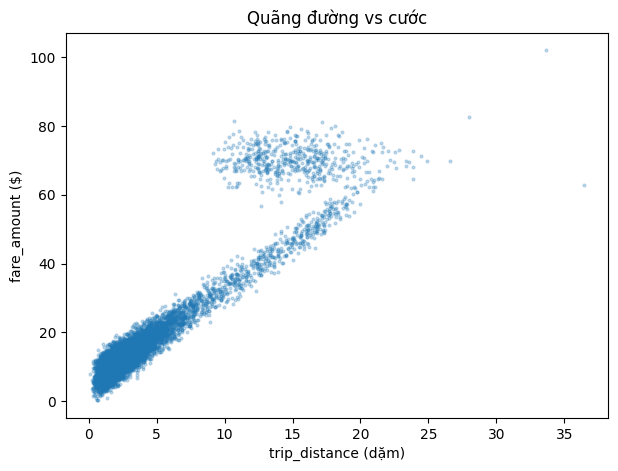

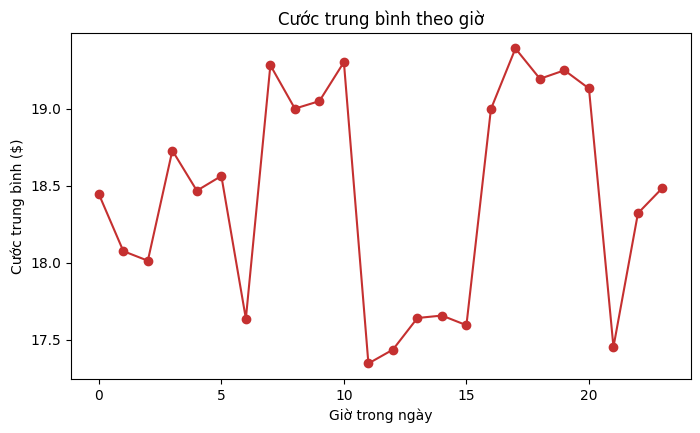

In [4]:
sample = df.sample(8000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["trip_distance"], sample[TARGET], s=4, alpha=0.25)
ax.set_xlabel("trip_distance (dặm)"); ax.set_ylabel("fare_amount ($)")
ax.set_title("Quãng đường vs cước")
plt.show()

avg_by_hour = df.groupby("hour")[TARGET].mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(avg_by_hour.index, avg_by_hour.values, "o-", color="#c53030")
ax.set_xlabel("Giờ trong ngày"); ax.set_ylabel("Cước trung bình ($)")
ax.set_title("Cước trung bình theo giờ")
plt.show()

**Nhận xét:** quan hệ quãng đường-cước gần tuyến tính nhưng có các "dải" phụ
phí rời rạc chồng lên (giờ cao điểm, congestion Manhattan). Cước trung bình theo
giờ có hai đỉnh rõ — khớp với hai khung giờ cao điểm đi làm/tan tầm.

## Bước 5 — Baseline: DummyRegressor(mean) và công thức tuyến tính thủ công

In [5]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
mae_dummy = mean_absolute_error(y_test, dummy.predict(X_test))

manual_pred = 3.0 + 2.8 * dist_test
mae_manual = mean_absolute_error(y_test, manual_pred)

print(f"DummyRegressor (mean):        MAE = ${mae_dummy:.2f}")
print(f"Công thức thủ công 3.0+2.8*km: MAE = ${mae_manual:.2f}")

DummyRegressor (mean):        MAE = $10.43
Công thức thủ công 3.0+2.8*km: MAE = $4.24


## Bước 6 — Cây KHÔNG giới hạn độ sâu -> chứng minh overfit

Độ sâu = 50, số lá = 146058
MAE train = $0.117  |  MAE test = $2.260


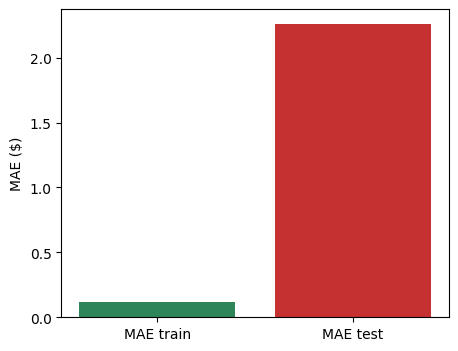

In [6]:
tree_full = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)
mae_train_full = mean_absolute_error(y_train, tree_full.predict(X_train))
mae_test_full = mean_absolute_error(y_test, tree_full.predict(X_test))
print(f"Độ sâu = {tree_full.get_depth()}, số lá = {tree_full.get_n_leaves()}")
print(f"MAE train = ${mae_train_full:.3f}  |  MAE test = ${mae_test_full:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["MAE train", "MAE test"], [mae_train_full, mae_test_full], color=["#2f855a", "#c53030"])
ax.set_ylabel("MAE ($)")
plt.show()

**Nhận xét:** MAE train gần như bằng 0 (cây học thuộc lòng từng điểm dữ liệu
train — mỗi lá có thể chỉ chứa 1 mẫu), trong khi MAE test cao hơn nhiều lần —
bằng chứng overfit kinh điển của cây không giới hạn độ sâu.

## Bước 7 — Quét max_depth = 1..20, chọn điểm tối ưu

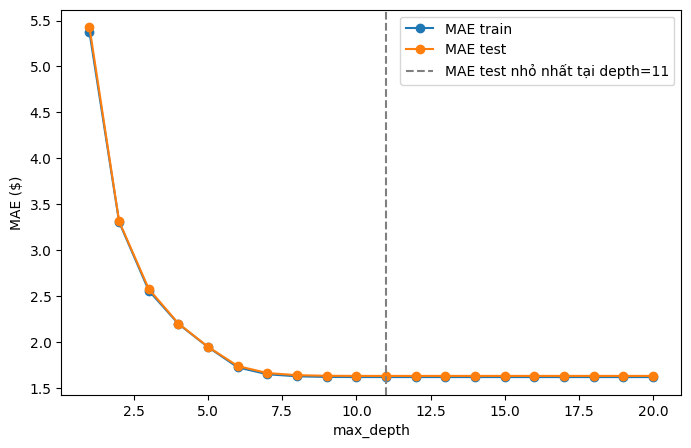

,max_depth,MAE_train,MAE_test,so_la
0,1,5.374744,5.429183,2
1,2,3.306321,3.313941,4
2,3,2.559237,2.577650,8
3,4,2.197057,2.201254,16
4,5,1.944131,1.947060,29
5,6,1.723928,1.738194,53
6,7,1.648865,1.662145,85
7,8,1.626756,1.638912,134
8,9,1.619726,1.632274,182
9,10,1.618410,1.631099,214


In [7]:
rows = []
for d in range(1, 21):
    t = DecisionTreeRegressor(max_depth=d, min_samples_leaf=500, random_state=RANDOM_STATE)
    t.fit(X_train, y_train)
    rows.append(dict(
        max_depth=d,
        MAE_train=mean_absolute_error(y_train, t.predict(X_train)),
        MAE_test=mean_absolute_error(y_test, t.predict(X_test)),
        so_la=t.get_n_leaves(),
    ))
depth_table = pd.DataFrame(rows)
best_depth = int(depth_table.loc[depth_table["MAE_test"].idxmin(), "max_depth"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_table["max_depth"], depth_table["MAE_train"], "o-", label="MAE train")
ax.plot(depth_table["max_depth"], depth_table["MAE_test"], "o-", label="MAE test")
ax.axvline(best_depth, color="gray", linestyle="--", label=f"MAE test nhỏ nhất tại depth={best_depth}")
ax.set_xlabel("max_depth"); ax.set_ylabel("MAE ($)"); ax.legend()
plt.show()
depth_table

**Nhận xét:** với `min_samples_leaf=500`, MAE test giảm nhanh tới depth≈6-7 rồi
gần như đi ngang — `min_samples_leaf` đã tự chặn overfit khá hiệu quả trong
khoảng độ sâu khảo sát. MAE test nhỏ nhất tuyệt đối rơi vào depth cao hơn nhưng
cải thiện không đáng kể so với depth=5, trong khi số lá tăng vọt (không tra tay
được nữa) — **bài chọn depth=5 theo yêu cầu nghiệp vụ**, không theo MAE nhỏ nhất
tuyệt đối.

## Bước 8 — Vẽ hàm dự đoán theo quãng đường -> nhìn thấy hình BẬC THANG

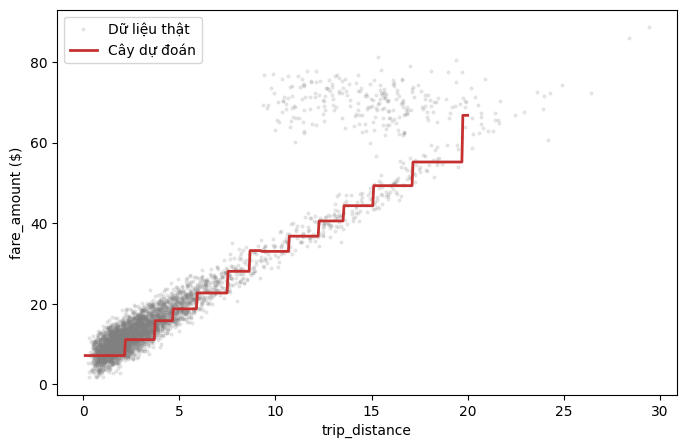

Số mức giá khác nhau trên lưới quét: 14


In [8]:
final_tree = DecisionTreeRegressor(max_depth=5, min_samples_leaf=500, random_state=RANDOM_STATE)
final_tree.fit(X_train, y_train)

dist_grid = np.linspace(0.1, 20, 400)
base_row = X_train.iloc[0:1].copy()
for c in X_train.columns:
    if c != "trip_distance":
        base_row[c] = X_train[c].mode().iloc[0]
grid_df = pd.concat([base_row] * len(dist_grid), ignore_index=True)
grid_df["trip_distance"] = dist_grid
pred_grid = final_tree.predict(grid_df)

fig, ax = plt.subplots(figsize=(8, 5))
s = df_train.sample(4000, random_state=RANDOM_STATE)
ax.scatter(s["trip_distance"], s[TARGET], s=4, alpha=0.15, color="gray", label="Dữ liệu thật")
ax.plot(dist_grid, pred_grid, color="#c53030", linewidth=2, label="Cây dự đoán")
ax.set_xlabel("trip_distance"); ax.set_ylabel("fare_amount ($)"); ax.legend()
plt.show()
print("Số mức giá khác nhau trên lưới quét:", len(np.unique(np.round(pred_grid, 4))))

**Nhận xét:** đường dự đoán là **hình bậc thang rõ rệt**, không mượt — mỗi bậc
tương ứng với một điều kiện chia (`threshold`) trong cây. Số mức giá quan sát
được đúng bằng số lá cây gặp phải khi quét quãng đường (giữ các biến khác cố
định).

## Bước 9 — Cây cuối max_depth=5 -> export_text + vẽ cây

In [9]:
pred_test = final_tree.predict(X_test)
mae = mean_absolute_error(y_test, pred_test)
mape = mean_absolute_percentage_error(y_test, pred_test)
rmse = root_mean_squared_error(y_test, pred_test)
print(f"Số lá = {final_tree.get_n_leaves()} | MAE=${mae:.2f} | MAPE={mape*100:.1f}% | RMSE=${rmse:.2f}")
print(export_text(final_tree, feature_names=list(X_train.columns))[:1200])

Số lá = 29 | MAE=$1.95 | MAPE=15.8% | RMSE=$2.59
|--- trip_distance <= 9.28
|   |--- trip_distance <= 3.70
|   |   |--- trip_distance <= 2.15
|   |   |   |--- zone_Manhattan <= 0.50
|   |   |   |   |--- is_rush <= 0.50
|   |   |   |   |   |--- value: [7.15]
|   |   |   |   |--- is_rush >  0.50
|   |   |   |   |   |--- value: [9.51]
|   |   |   |--- zone_Manhattan >  0.50
|   |   |   |   |--- is_rush <= 0.50
|   |   |   |   |   |--- value: [9.87]
|   |   |   |   |--- is_rush >  0.50
|   |   |   |   |   |--- value: [12.23]
|   |   |--- trip_distance >  2.15
|   |   |   |--- zone_Manhattan <= 0.50
|   |   |   |   |--- is_rush <= 0.50
|   |   |   |   |   |--- value: [11.10]
|   |   |   |   |--- is_rush >  0.50
|   |   |   |   |   |--- value: [13.40]
|   |   |   |--- zone_Manhattan >  0.50
|   |   |   |   |--- is_rush <= 0.50
|   |   |   |   |   |--- value: [13.81]
|   |   |   |   |--- is_rush >  0.50
|   |   |   |   |   |--- value: [16.19]
|   |--- trip_distance >  3.70
|   |   |--- trip_d

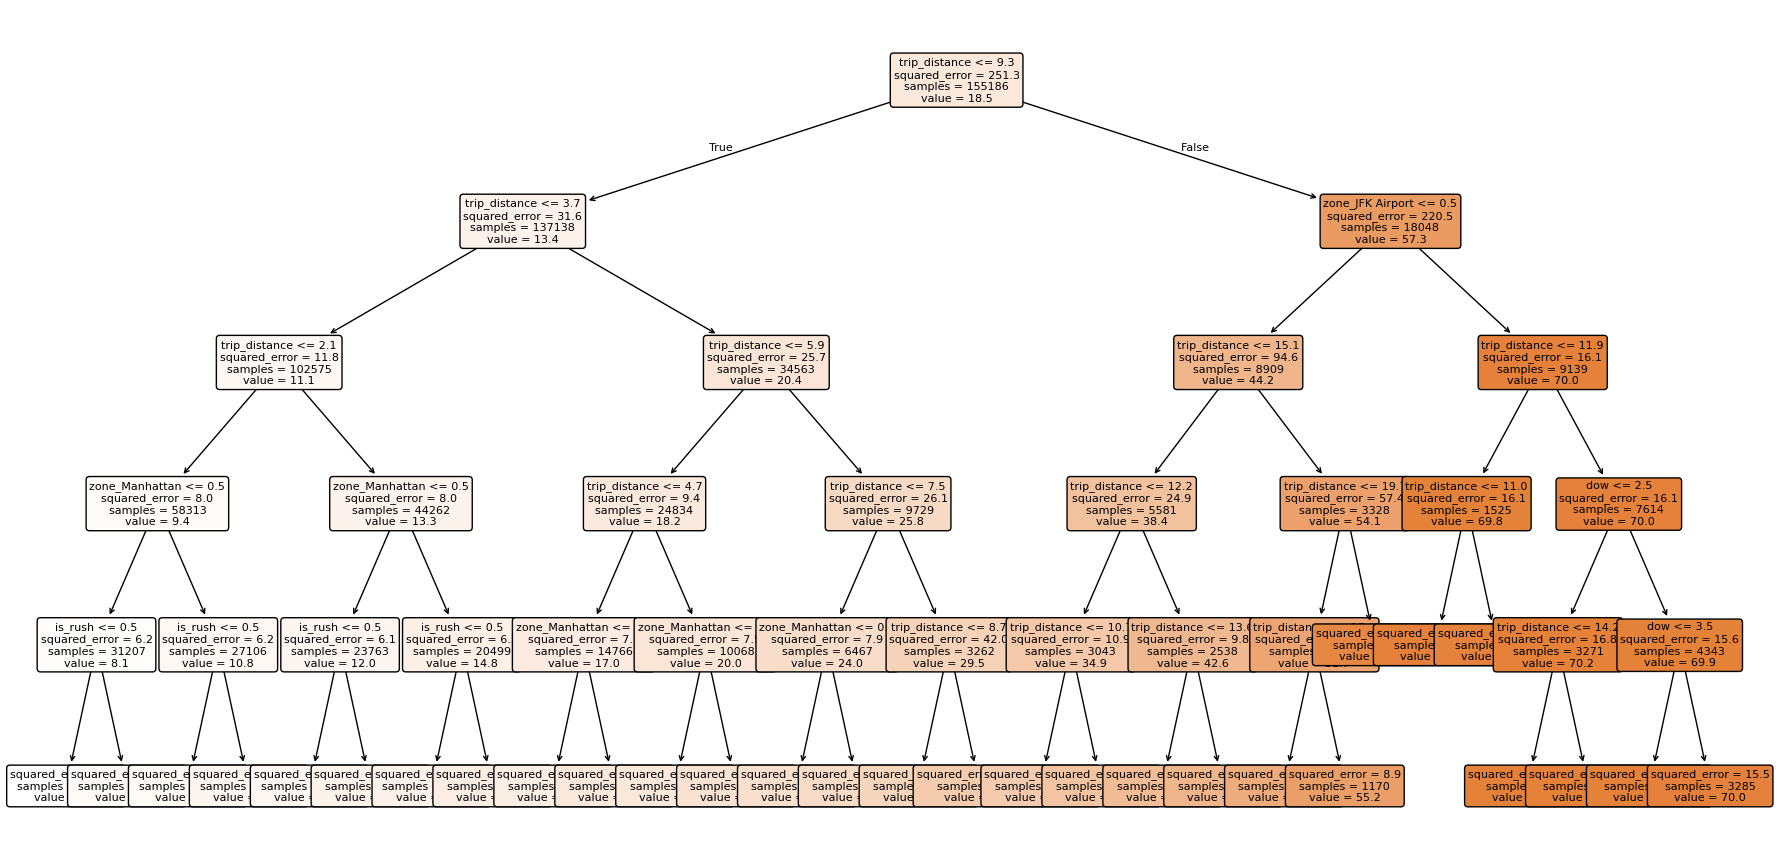

In [10]:
fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(final_tree, feature_names=list(X_train.columns), filled=True, rounded=True, fontsize=8, ax=ax, precision=1)
plt.show()

## Bước 10 — Chuyển cây thành BẢNG TRA CƯỚC

In [11]:
def tree_to_rate_table(tree, feature_names):
    t = tree.tree_
    rows = []
    def recurse(node, conditions):
        if t.children_left[node] == t.children_right[node]:
            rows.append(dict(
                dieu_kien=" VÀ ".join(conditions) if conditions else "(mọi chuyến)",
                gia_du_doan_usd=round(float(t.value[node][0][0]), 2),
                so_chuyen_train=int(t.n_node_samples[node]),
            ))
            return
        feat = feature_names[t.feature[node]]; thr = t.threshold[node]
        recurse(t.children_left[node], conditions + [f"{feat} <= {thr:.2f}"])
        recurse(t.children_right[node], conditions + [f"{feat} > {thr:.2f}"])
    recurse(0, [])
    table = pd.DataFrame(rows).sort_values("gia_du_doan_usd").reset_index(drop=True)
    table.insert(0, "ma_muc_gia", [f"G{i+1:02d}" for i in range(len(table))])
    return table

rate_table = tree_to_rate_table(final_tree, list(X_train.columns))
rate_table.to_csv("../outputs/bang_tra_cuoc.csv", index=False)
rate_table

,ma_muc_gia,dieu_kien,gia_du_doan_usd,so_chuyen_train
0,G01,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,7.15,18251
1,G02,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,9.51,12956
2,G03,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,9.87,16054
3,G04,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,11.10,14066
4,G05,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,12.23,11052
5,G06,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,13.40,9697
6,G07,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,13.81,12099
7,G08,trip_distance <= 9.28 VÀ trip_distance > 3.70 ...,15.79,8067
8,G09,trip_distance <= 9.28 VÀ trip_distance <= 3.70...,16.19,8400
9,G10,trip_distance <= 9.28 VÀ trip_distance > 3.70 ...,18.52,6699


## Bước 11 — Kiểm tra sai số ±15% (yêu cầu nghiệp vụ)

In [12]:
pct_err = np.abs(pred_test - y_test.values) / y_test.values
within15 = (pct_err <= 0.15).mean() * 100
print(f"{within15:.1f}% số chuyến test có sai số trong ±15%")

64.9% số chuyến test có sai số trong ±15%


**Nhận xét:** tỉ lệ đạt ±15% chưa đạt 100% — đây là đánh đổi thật giữa yêu cầu
"tra được bằng tay" (cây nông, ít lá) và yêu cầu "chính xác ±15%". Có thể nới
depth lên (bước 7 cho thấy MAE giảm thêm không nhiều) hoặc chấp nhận sai số cao
hơn ở phân khúc chuyến dài/hiếm gặp.

## Bước 12 — So sánh với Random Forest và Linear Regression

In [13]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

compare = pd.DataFrame([
    dict(model="DecisionTree depth=5", MAE=mae, MAPE=mape*100, RMSE=rmse),
    dict(model="RandomForest", MAE=mean_absolute_error(y_test, pred_rf),
         MAPE=mean_absolute_percentage_error(y_test, pred_rf)*100,
         RMSE=root_mean_squared_error(y_test, pred_rf)),
    dict(model="LinearRegression", MAE=mean_absolute_error(y_test, pred_lin),
         MAPE=mean_absolute_percentage_error(y_test, pred_lin)*100,
         RMSE=root_mean_squared_error(y_test, pred_lin)),
]).round(3)
compare

,model,MAE,MAPE,RMSE
0,DecisionTree depth=5,1.947,15.842,2.591
1,RandomForest,1.591,12.586,2.172
2,LinearRegression,1.874,13.807,2.862


**Nhận xét:** Random Forest chính xác hơn nhưng không tra tay được (200 cây).
Linear Regression thua cây depth=5 vì các phụ phí (giờ cao điểm, congestion, sân
bay) là các bước nhảy CỘNG THÊM rời rạc, không phải quan hệ tuyến tính liên tục
với các biến đầu vào — đúng loại cấu trúc mà cây quyết định nắm bắt tự nhiên hơn
hồi quy tuyến tính.

## Vì sao cây KHÔNG ngoại suy được (chuyến 200 km sẽ ra sao?)

In [14]:
x_200km = X_train.iloc[0:1].copy()
x_200km["trip_distance"] = 200.0
print("Dự đoán cho chuyến 200 km:", round(float(final_tree.predict(x_200km)[0]), 2), "$")
print("Giá cao nhất từng thấy trong bảng tra:", rate_table["gia_du_doan_usd"].max(), "$")

Dự đoán cho chuyến 200 km: 66.75 $
Giá cao nhất từng thấy trong bảng tra: 70.23 $


**Giải thích:** cây quyết định chỉ có thể trả về giá trị **trung bình của một
lá đã học từ dữ liệu train**. Với `trip_distance=200` (vượt xa dải train, tối đa
quanh 20-30 dặm), mẫu vẫn rơi vào đúng lá "xa nhất" (`trip_distance > 19.71`...)
và nhận **đúng giá của lá đó**, dù quãng đường gấp 10 lần — cây **không thể
ngoại suy tuyến tính** như hồi quy, vì lá là hằng số, không phải hàm theo x.

## Lưu model cuối

In [15]:
import joblib
joblib.dump(final_tree, "../models/tree_reg.joblib")
print("Đã lưu models/tree_reg.joblib")

Đã lưu models/tree_reg.joblib
